## (Problem Statement & Objective)

### 1. Problem Statement
The bank wants to optimize its marketing campaigns for personal loans. Currently, reaching out to every customer is inefficient, costly, and leads to low conversion rates. 

### 2. Business Objective
To predict which customers are highly likely to accept a personal loan offer based on their demographic and banking history. 

### 3. Measurable Goal
By identifying potential loan acceptors, the bank can run a targeted marketing campaign. This will:
* Increase the conversion rate (loan acceptance).
* Reduce marketing operational costs.
* Improve customer experience by not bothering uninterested clients.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bank-full.csv", sep=';')
bank = df.copy()


In [3]:
print(f"\n shape of bank datset: {bank.shape}")
print(f"\n columns of bank datset: {bank.columns}")
print(f"\n duplicates in bank datset: {bank.duplicated().sum()}")
print(f"\n missing value in bank datset:\n{bank.isnull().sum()}")
print(f"\n shape of bank datset:\n{bank.dtypes}")
print(f"\n Top 5 data:\n{bank.head()}")


 shape of bank datset: (45211, 17)

 columns of bank datset: Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

 duplicates in bank datset: 0

 missing value in bank datset:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

 shape of bank datset:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

 Top 5 data:
   

observation:
* The dataset consists of 45,211 rows and 17 columns.
* There are no traditional missing values (NaN / Null) or duplicate rows.
* The dataset contains 10 object (categorical) columns and 7 integer (numerical) columns.
* Note: Although there are no formal null values, some columns (like job and education) contain "unknown" values, which act as hidden missing data.

In [4]:
print(f"statistical summary \n {bank.describe()}")


statistical summary 
                 age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%  

In [5]:
# Print each object column and its unique value counts on a single line
for col in df.select_dtypes(include=['object']).columns:
    counts_dict = df[col].value_counts()
    print(f"{col} : {counts_dict}")

job : job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
marital : marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education : education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
default : default
no     44396
yes      815
Name: count, dtype: int64
housing : housing
yes    25130
no     20081
Name: count, dtype: int64
loan : loan
no     37967
yes     7244
Name: count, dtype: int64
contact : contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
month : month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Nam

Observation
##### Numerical Features
* Age & Balance: Customer age goes up to 95, but 75% are under 48. Balance has a massive maximum value of 102,127 compared to a median of 448. Both indicate strong right-skewness and outliers.
* Duration & Campaign: duration (max 4,918s vs median 180s) and campaign (max 63 vs median 2) have heavy outliers, meaning a few customers were called repeatedly for a very long time.
* Pdays & Previous: pdays has a median of -1 (meaning most customers were never contacted before). The max values (871 days and 275 contacts) are extreme outliers.

##### 2. Categorical Features
* Demographics: Married individuals dominate the dataset. secondary education is the most common. Top 3 jobs are Blue-collar, Management, and Technician.
* Target Variable (y) Imbalance:** Highly imbalanced data. Only 11.7% (5,289) accepted the loan offer (yes), while 88.3% (39,922) rejected it (no).
* Missing/Unknown Data:** poutcome (Previous campaign outcome) is heavily flooded with "unknown" values (36,959 rows), making this column less reliable.
* Timeline: May is the peak month for marketing contacts, and Cellular is the preferred communication mode.

In [6]:
bank.rename(columns={'y': 'loan_accepted'}, inplace=True)

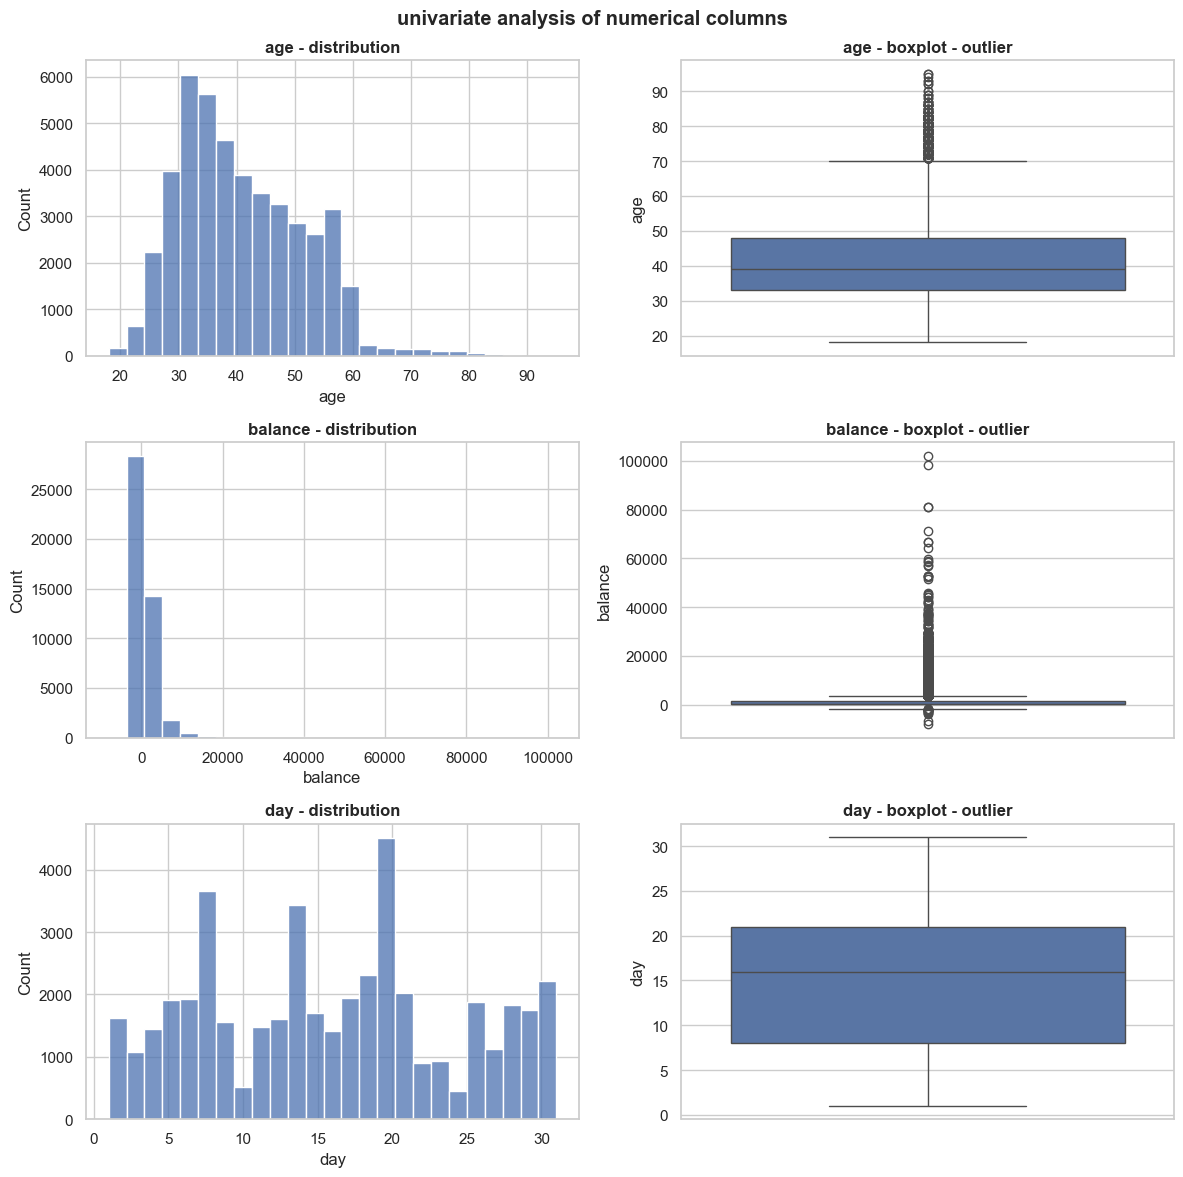

In [7]:
#EDA
#univariate analysis of numerical col
sns.set_theme(style="whitegrid")

num_col_1 = ["age", "balance", "day"]

fig, axes = plt.subplots(3, 2, figsize=(12,12))

for i, col, in enumerate(num_col_1):
    sns.histplot(data=bank, x=col, ax=axes[i][0], bins=25)
    axes[i][0].set_title(f"{col} - distribution", weight='bold')

    sns.boxplot(data=bank, y=col, ax=axes[i][1])
    axes[i][1].set_title(f"{col} - boxplot - outlier", weight='bold')

plt.suptitle("univariate analysis of numerical columns", weight='bold')
plt.tight_layout()
plt.show()

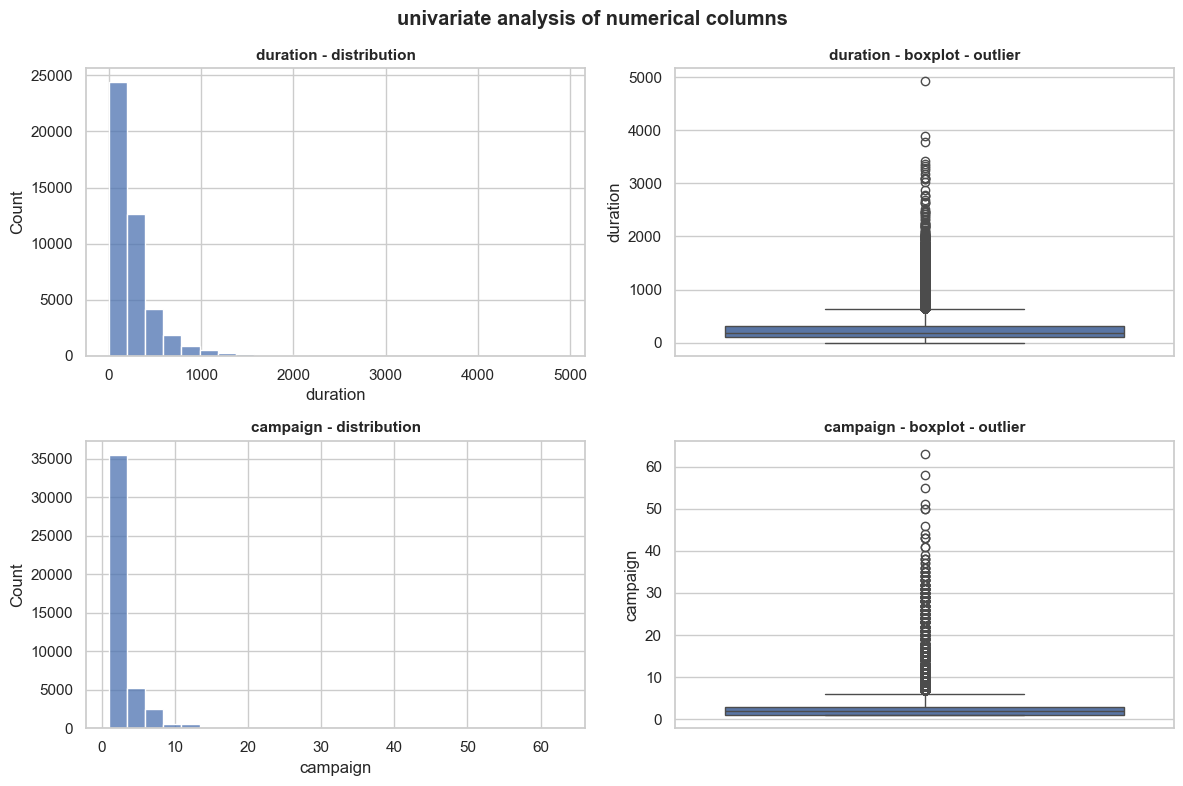

In [8]:
#univariate analysis of numerical col
num_col_2 = ["duration", "campaign"]


fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, col, in enumerate(num_col_2):
    sns.histplot(data=bank, x=col, ax=axes[i][0], bins=25)
    axes[i][0].set_title(f"{col} - distribution",fontsize=11, weight='bold')

    sns.boxplot(data=bank, y=col, ax=axes[i][1])
    axes[i][1].set_title(f"{col} - boxplot - outlier", fontsize=11, weight='bold')

plt.suptitle("univariate analysis of numerical columns", weight='bold')
plt.tight_layout()
plt.show()

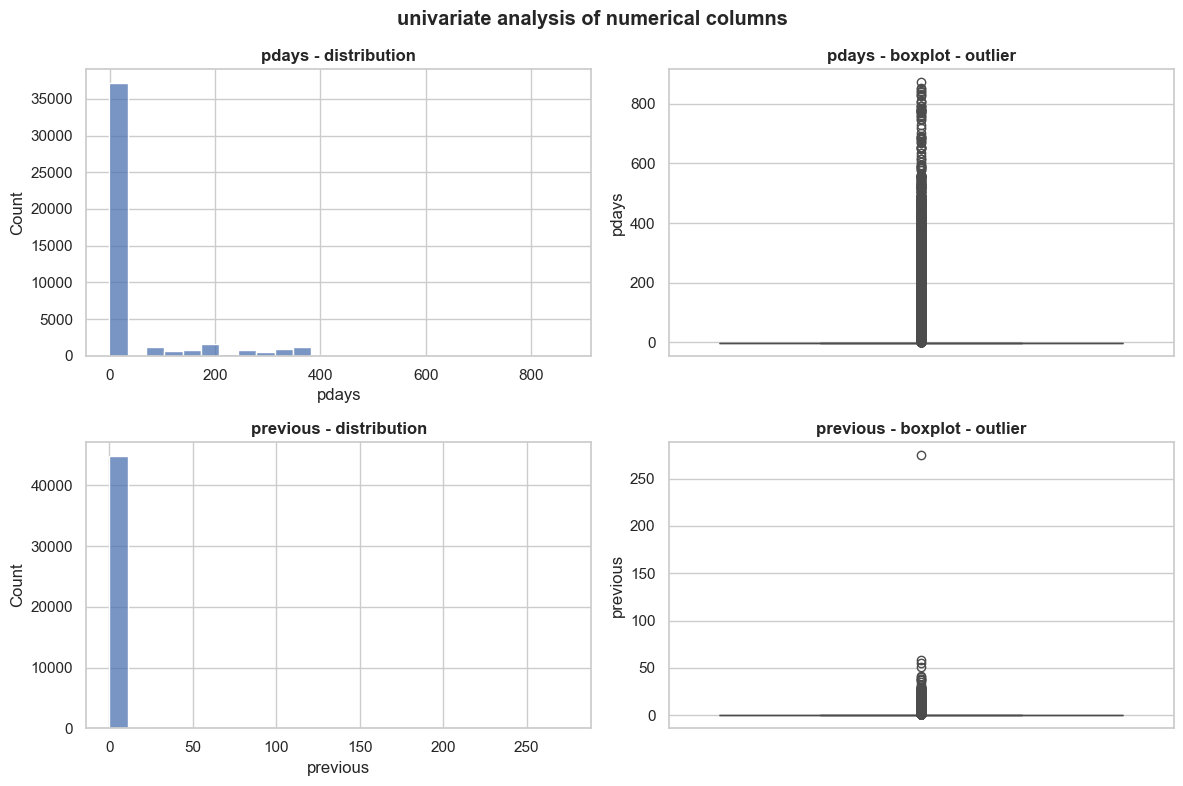

In [9]:
#univariate analysis of numerical col
num_col_3 = ["pdays", "previous"]


fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, col, in enumerate(num_col_3):
    sns.histplot(data=bank, x=col, ax=axes[i][0], bins=25)
    axes[i][0].set_title(f"{col} - distribution",weight='bold')

    sns.boxplot(data=bank, y=col, ax=axes[i][1])
    axes[i][1].set_title(f"{col} - boxplot - outlier", weight='bold')

plt.suptitle("univariate analysis of numerical columns", weight='bold')
plt.tight_layout()
plt.show()

Observation: Age distribution shows that most bank customers are between 30 and 45 years old, with few outliers after 70. Balance histogram shows most people have a balance between 0 and 5K, indicating high outliers up to 100K+. Day column looks normal and has no outliers. Duration is highly right-skewed with most calls being very short, but heavy outliers exist between 700 and 3000 seconds. Campaign has a high count at 1, with outliers stretching up to 12 calls. Pdays and Previous columns do not show a proper boxplot because the majority of data points are concentrated at -1 and 0 since most customers are new

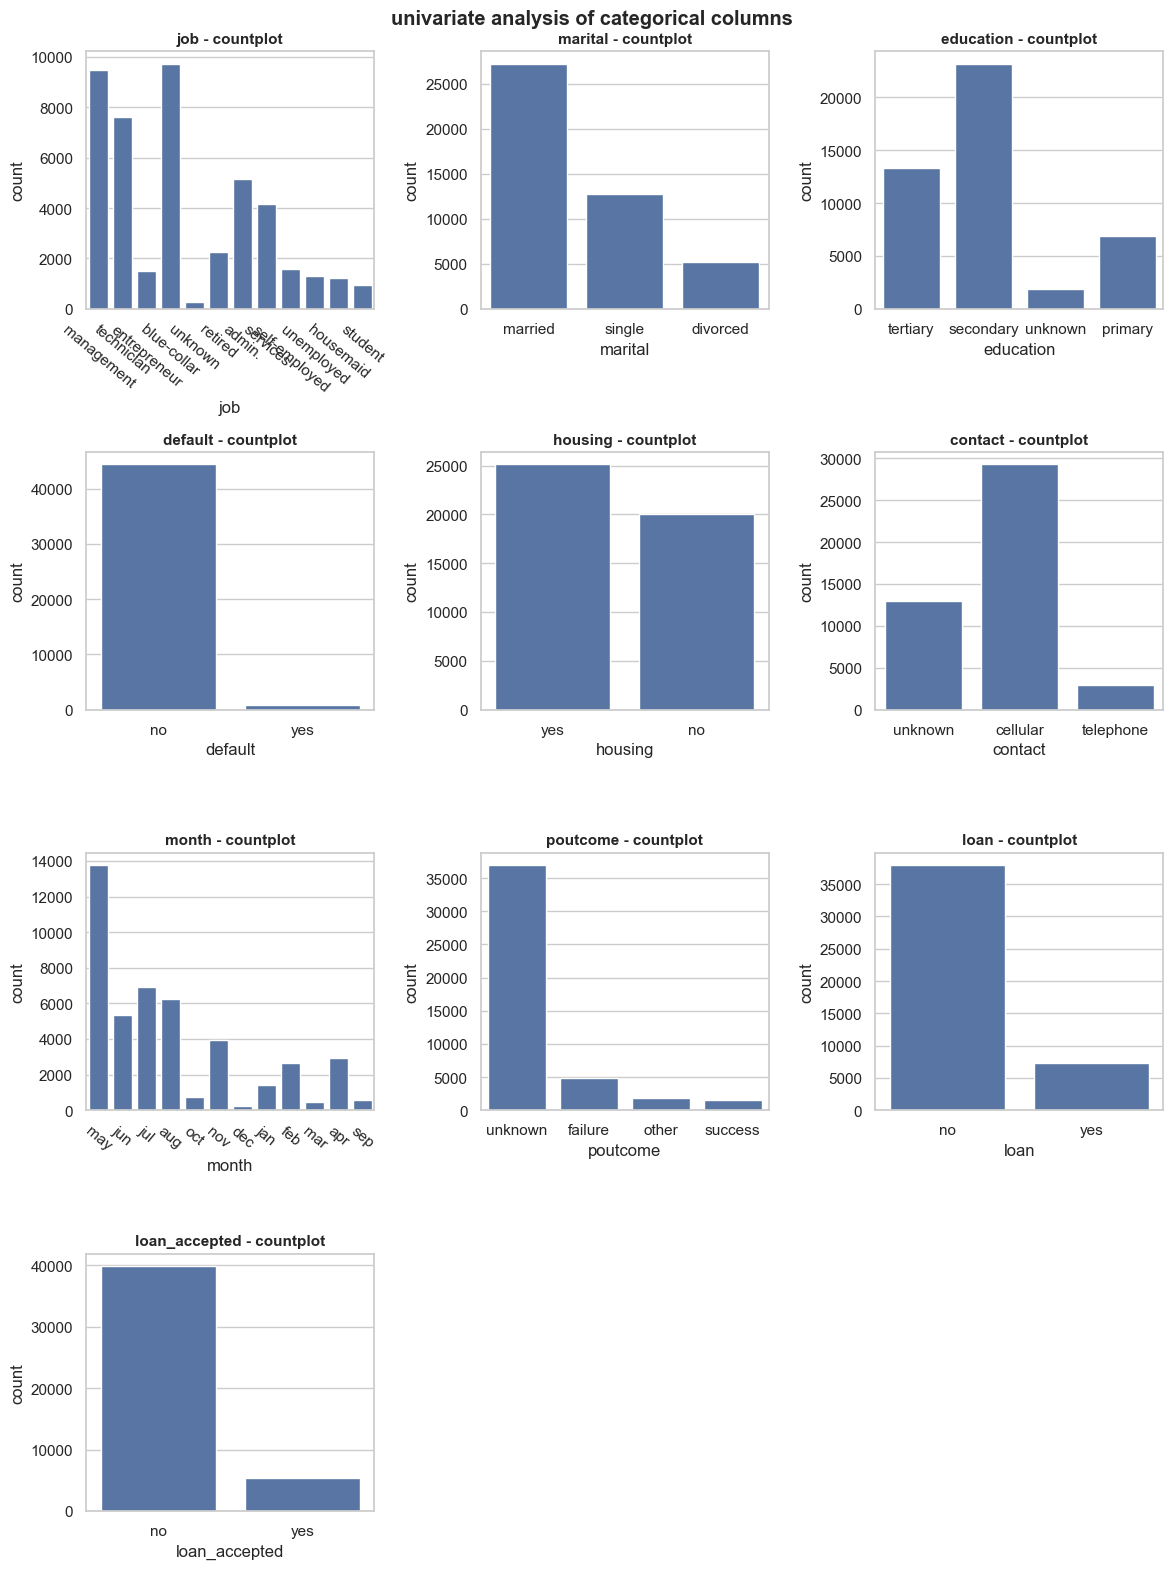

In [10]:
# univariate analysis of categorical columns

cat_col = ["job", "marital", "education", "default", "housing", "contact", "month", "poutcome", "loan", "loan_accepted"]

fig, axes = plt.subplots(4, 3, figsize=(12,16))
axes = axes.flatten()


for i, col in enumerate(cat_col):
    sns.countplot(data=bank, x=col, ax=axes[i])
    axes[i].set_title(f"{col} - countplot", fontsize=11, weight='bold')
    #adding if conding so that label show clearly
    if col in ["job", "month"]:
        axes[i].tick_params(axis='x', labelrotation=-40)

plt.suptitle("univariate analysis of categorical columns", weight='bold')
plt.tight_layout()
axes[10].set_visible(False)
axes[11].set_visible(False)
plt.show()



"Blue collar, management, and technician are the dominant job types in the dataset. Married individuals are the largest group with over 25K counts, followed by singles and then divorcees. Most customers have a secondary education, while tertiary is the second most common. Very few customers have a history of credit default, showing that the bank targets financially stable people. A majority of customers already have a housing loan, but very few have a personal loan. Cellular is the most common communication type, while a significant portion remains unknown. May is the peak month for marketing contacts, while June, July, and August show moderate activity. The previous campaign outcome is mostly unknown, indicating a huge number of new customers. Finally, the target variable y is highly imbalanced as only a small minority accepted the personal loan offer."


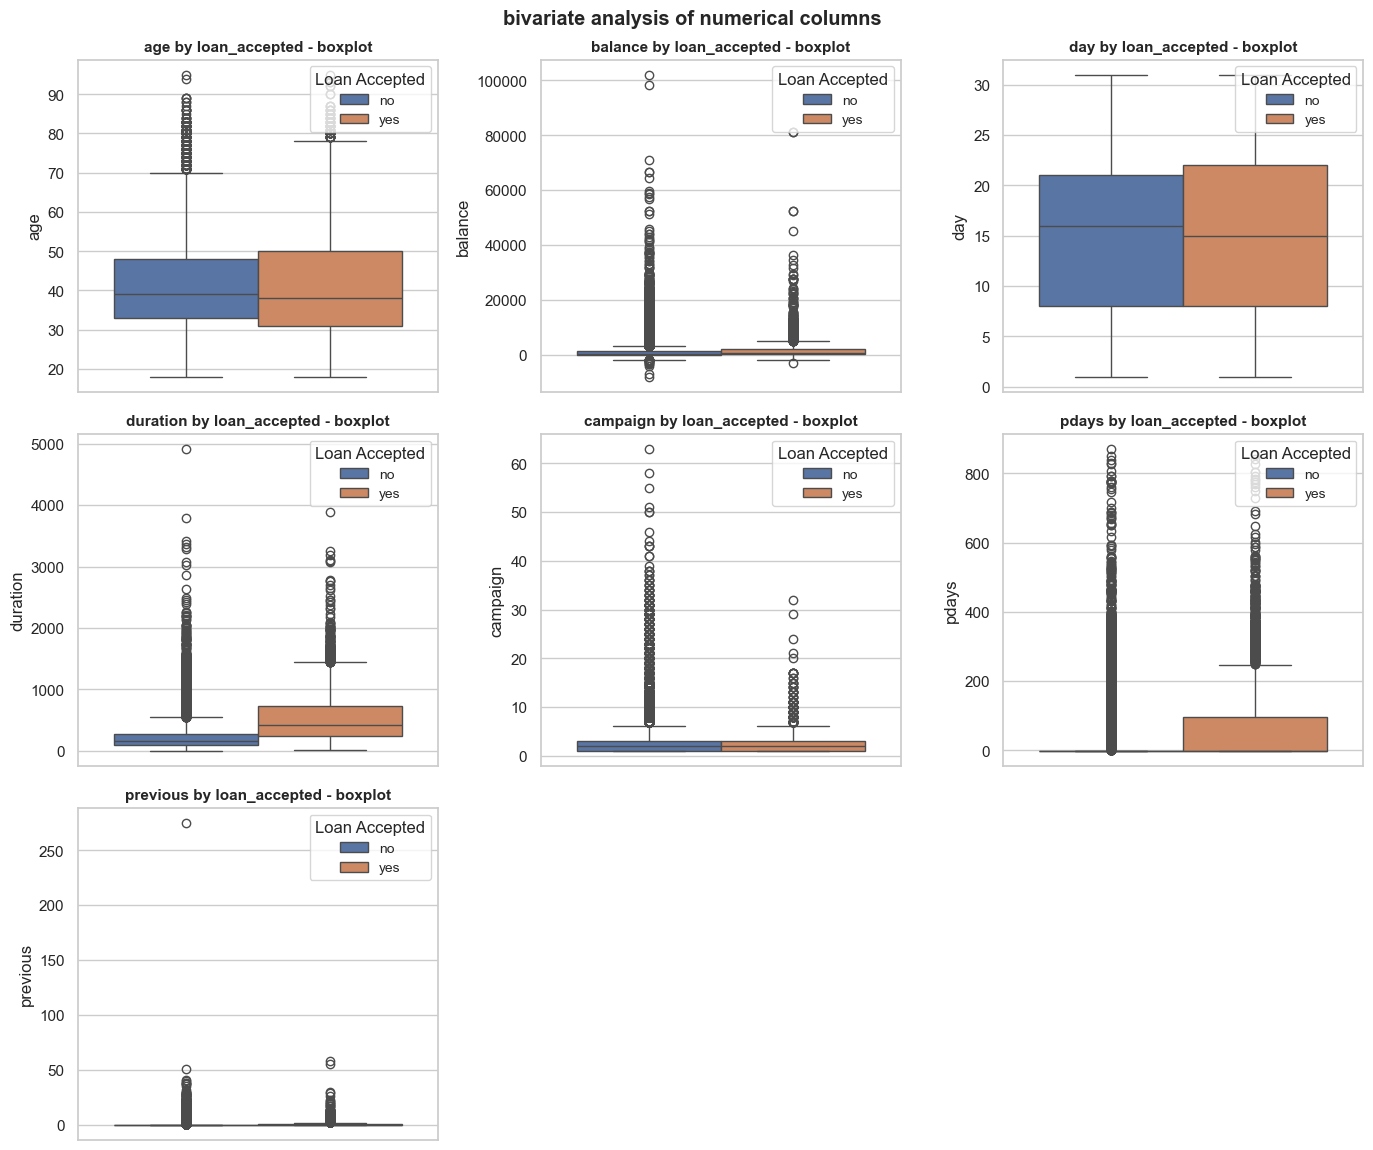

In [11]:
#bivariate analysis of numerical columns

bi_num = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(bi_num):
    sns.boxplot(data=bank, y=col, hue="loan_accepted", ax=axes[i])
    axes[i].set_title(f"{col} by loan_accepted - boxplot", fontsize=11, weight='bold')
    axes[i].legend(loc="upper right", fontsize="small", title="Loan Accepted")

plt.suptitle("bivariate analysis of numerical columns", weight='bold')
plt.tight_layout()
axes[7].set_visible(False)
axes[8].set_visible(False)
plt.show()

observation: Customers who accepted the loan offer tend to have a slightly lower median age but a wider age range. For the balance column, people with massive account balances generally did not accept the loan offer, while the acceptance group has a slightly higher and more stable median balance. Call duration is the strongest factor as customers who accepted the loan spent significantly more time on the call with a boxplot extending up to 1500 seconds. In contrast, those who rejected the loan had much shorter calls. For the campaign column, customers who said no were called repeatedly with extreme outliers up to 60 times, while those who said yes were mostly contacted fewer times. In pdays, the loan rejection group shows no boxplot due to new customers, whereas the acceptance group clearly shows that customers contacted within the last 250 days had a higher chance of saying yes.

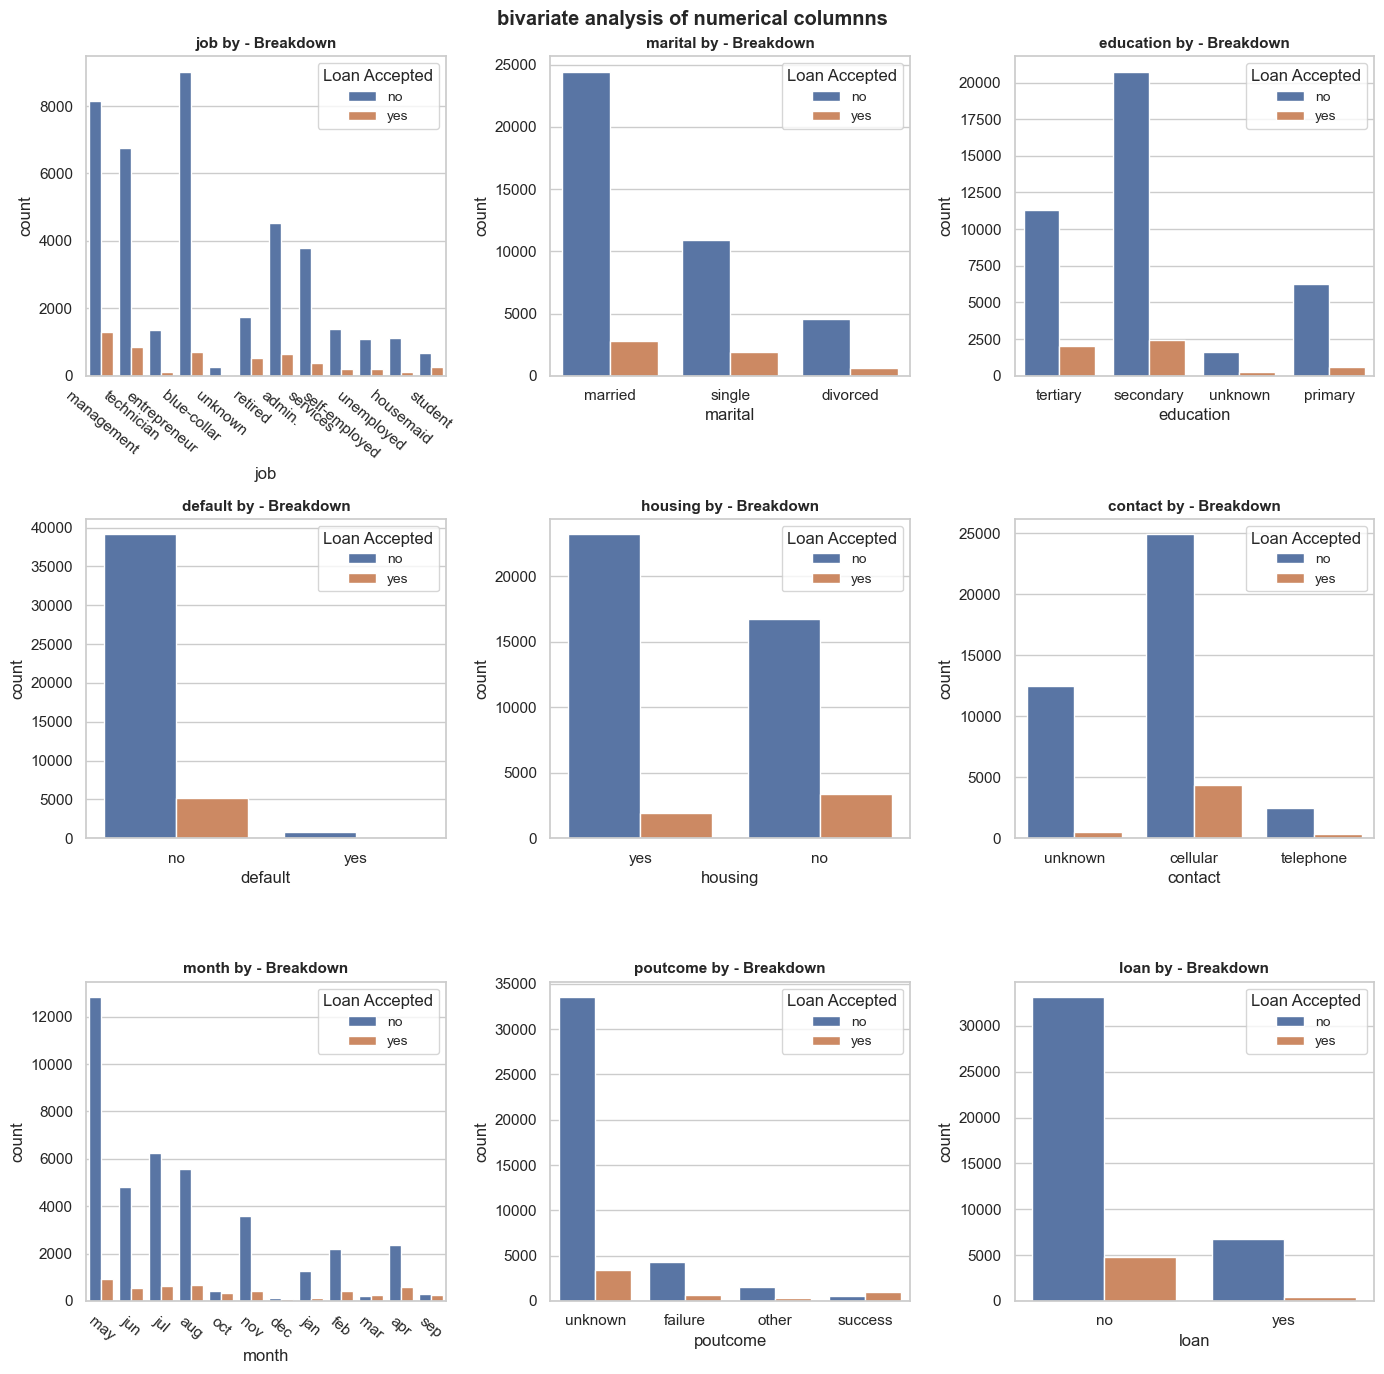

In [12]:
#bivariate analysis of categorical columns

bi_cat = ["job", "marital", "education", "default", "housing", "contact", "month", "poutcome", "loan"]


fig, axes = plt.subplots(3, 3, figsize=(14,14))
axes = axes.flatten()

for i, col in enumerate(bi_cat):
    sns.countplot(data=bank, x=col, hue="loan_accepted", ax=axes[i])
    axes[i].set_title(f"{col} by - Breakdown", fontsize=11, weight='bold')
    axes[i].legend(loc="upper right", fontsize="small", title="Loan Accepted")
    if col in ["job", "month"]:
        axes[i].tick_params(axis='x', labelrotation=-40)

plt.suptitle("bivariate analysis of numerical columnns", weight='bold')
plt.tight_layout()
plt.show()

observation: Management, technician, and blue-collar workers contribute to the highest number of loan acceptances, though their rejection counts are also high. Married individuals form the largest chunk of loan buyers, followed by single people. Secondary and tertiary educated individuals are the primary groups accepting the loan offer. Customers with no credit default history are almost the only ones accepting the loan, meaning the bank should avoid defaulters. Interestingly, people who do not already have a housing loan or a personal loan show a higher volume of loan acceptances, which means the bank should target debt-free individuals. Marketing via cellular phones brings the highest conversions compared to telephone or unknown methods. May, June, July, and August see the most loan acceptances, confirming these are peak campaigning months. Lastly, even though the previous campaign outcome is mostly unknown, the success category shows a high proportion of loan acceptances relative to its total count

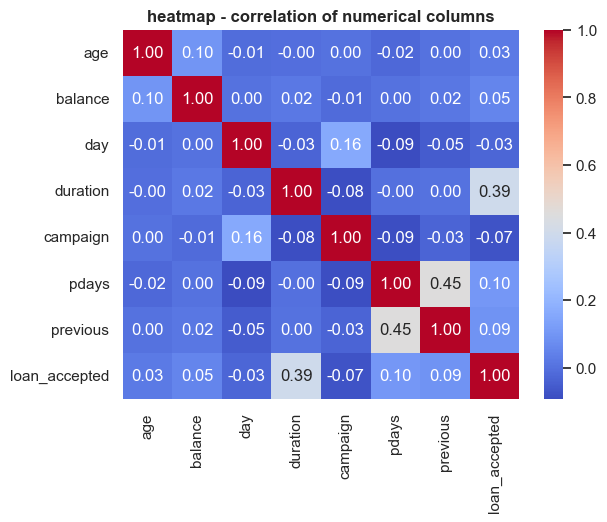

In [13]:
#multivariate analysis using heatmap for numerical col
bank["loan_accepted"] = bank["loan_accepted"].str.lower().str.strip()
bank["loan_accepted"]= bank["loan_accepted"].map({'yes': 1, 'no': 0}) 
bank_corr = bank.corr(numeric_only=True)
sns.heatmap(data=bank_corr, annot=True, cmap="coolwarm", fmt='.2f')
plt.title("heatmap - correlation of numerical columns", weight='bold')
plt.show()

Observation: Duration has the highest positive correlation of 0.39 with loan_accepted, proving it is the most important numerical predictor where longer conversations strongly relate to offer acceptance. Both pdays with 0.10 and previous with 0.09 show a mild positive correlation with the target variable, while balance has a very weak relationship of 0.05. A notable internal correlation of 0.45 exists between pdays and previous, suggesting redundant information between these two features. Other pairs like day and campaign show a minor correlation of 0.16 but do not relate significantly to loan acceptance.

## Feature Selaction Using Random Forest Tree 

In [14]:
#Feature Preprocessing
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Copy original dataframe
FS = bank.copy()

#Label Encode 
le = LabelEncoder()
FS["loan"] = le.fit_transform(FS["loan"])
FS["default"] = le.fit_transform(FS["default"])
FS["housing"] = le.fit_transform(FS["housing"])

#One-Hot Encode multi-class categories
multi_cols = ["job", "marital", "education", "contact", "month", "poutcome"]
FS = pd.get_dummies(FS, columns=multi_cols, drop_first=True, dtype=int)

X = FS.drop(columns=['loan_accepted'])
y = FS['loan_accepted']

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Train Random Forest Model
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

#Extracting Feature Importances
feature_imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
feature_imp = feature_imp.sort_values(by='Importance', ascending=False)

print(feature_imp.head(15))


                Feature  Importance
6              duration    0.275762
2               balance    0.101239
0                   age    0.096619
5                   day    0.088298
40     poutcome_success    0.053814
8                 pdays    0.041852
7              campaign    0.038852
9              previous    0.020992
3               housing    0.019948
27      contact_unknown    0.013982
23  education_secondary    0.013268
34            month_mar    0.012909
21      marital_married    0.012401
24   education_tertiary    0.011659
33            month_jun    0.011594


In [15]:
#Scaling:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

FS["age"]= scaler.fit_transform(FS[["age"]])
FS["balance"] = scaler.fit_transform(FS[["balance"]])
FS["duration"] = scaler.fit_transform(FS[["duration"]])

FS.head()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,1.606965,0,0.256419,1,0,5,0.011016,1,-1,0,...,0,0,0,1,0,0,0,0,0,1
1,0.288529,0,-0.437895,1,0,5,-0.416127,1,-1,0,...,0,0,0,1,0,0,0,0,0,1
2,-0.747384,0,-0.446762,1,1,5,-0.707361,1,-1,0,...,0,0,0,1,0,0,0,0,0,1
3,0.571051,0,0.047205,1,0,5,-0.645231,1,-1,0,...,0,0,0,1,0,0,0,0,0,1
4,-0.747384,0,-0.447091,0,0,5,-0.233620,1,-1,0,...,0,0,0,1,0,0,0,0,0,1


<h2 style="text-align: center;">Machine learning</h2>

### Logistic Regression

In [16]:
# Initializing, training, and evaluating a logistic Regression model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score ,confusion_matrix
from sklearn.model_selection import train_test_split

model_bank = FS[['duration', 'balance', 'age', 'day', 'poutcome_success', 'pdays', 'campaign', 'previous', 'housing', 'contact_unknown', 'education_secondary', 'month_mar', 'marital_married', 'education_tertiary', 'month_jun', "loan_accepted"]]

# Separating features from the target variable
X = model_bank.drop(columns=['loan_accepted'])
y = model_bank['loan_accepted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Logistic Regression with balanced weights to handle class imbalance
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Generating predictions on the unseen test set
Bank_test_pred = model.predict(X_test)

# Displaying model evaluation performance results
Bank_accuracy = accuracy_score(y_test, Bank_test_pred)
Bank_precision = precision_score(y_test, Bank_test_pred)
Bank_recall= recall_score(y_test, Bank_test_pred)
Bank_cm = confusion_matrix(y_test, Bank_test_pred)

print(f"Bank Accuracy Score = {Bank_accuracy}")
print(f"Bank precision Score = {Bank_precision}")
print(f"Bank recall Score = {Bank_recall}")
print(f"Bank confusion matrix = {Bank_cm}")

Bank Accuracy Score = 0.8339046776512219
Bank precision Score = 0.4032941176470588
Bank recall Score = 0.7855178735105408
Bank confusion matrix = [[6684 1268]
 [ 234  857]]


### DEcision Tree

In [17]:
# Initializing, training, and evaluating a Decision Tree model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=50, random_state=42)

model.fit(X_train, y_train)
bank_test_pred = model.predict(X_test)

# Displaying model evaluation performance results of decision tree
bank_accuracy = accuracy_score(y_test, bank_test_pred)
bank_precision = precision_score(y_test, bank_test_pred)
bank_recall= recall_score(y_test, bank_test_pred)
bank_cm = confusion_matrix(y_test, bank_test_pred)

print(f"bank Accuracy Score = {bank_accuracy}")
print(f"bank precision Score = {bank_precision}")
print(f"bank recall Score = {bank_recall}")
print(f"bank confusion matrix = {bank_cm}")

bank Accuracy Score = 0.8018356740019905
bank precision Score = 0.3569971440228478
bank recall Score = 0.8020164986251146
bank confusion matrix = [[6376 1576]
 [ 216  875]]


### Random forest Tree

In [18]:
# Initializing, training, and evaluating a Random forest tree model
from sklearn.ensemble import RandomForestClassifier



bank = RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', max_depth=5, min_samples_leaf=50, random_state=42)

bank.fit(X_train, y_train)
bank_test_pred = bank.predict(X_test)

# Displaying model evaluation performance results of Random forest tree
bank_accuracy = accuracy_score(y_test, bank_test_pred)
bank_precision = precision_score(y_test, bank_test_pred)
bank_recall= recall_score(y_test, bank_test_pred)
bank_cm = confusion_matrix(y_test, bank_test_pred)

print(f"bank Accuracy Score = {bank_accuracy}")
print(f"bank precision Score = {bank_precision}")
print(f"bank recall Score = {bank_recall}")
print(f"bank confusion matrix = {bank_cm}")

bank Accuracy Score = 0.7936525489328763
bank precision Score = 0.35181644359464626
bank recall Score = 0.843263061411549
bank confusion matrix = [[6257 1695]
 [ 171  920]]


We tried multiple models, and the Random Forest model performed the best in capturing customers who will accept the loan. Although the overall accuracy dropped slightly and precision was significantly affected, our main objective—which was maximizing the Recall score—was successfully achieved.

### Conclusion:
The goal was to predict which bank customers are likely to accept a personal loan offer, helping the bank run targeted and cost-effective marketing campaigns.
The dataset had 45,211 rows and 17 columns. No missing values or duplicates were found, though some columns like job and education contained 'unknown' values acting as hidden missing data. The target variable was highly imbalanced only 11.7% customers accepted the loan.
EDA revealed that most customers are married, aged 30–45, with secondary education and blue-collar or management jobs. High call duration strongly correlated with loan acceptance — longer conversations meant higher conversion. Customers with no credit default and no existing loans were most likely to accept. May was the peak marketing month. Interestingly, high-balance customers rarely accepted the offer.
For modeling, categorical columns were label encoded or one-hot encoded, and a Random Forest was used for feature selection top features were duration, balance, age, day, and previous campaign success. Numerical columns were scaled.
Three models were trained Logistic Regression (recall 0.79), Decision Tree (recall 0.80), and Random Forest (recall 0.84). Since the business goal was to avoid missing potential loan acceptors, recall was our primary metric. Random Forest achieved the best recall of 84%, capturing 920 out of 1,091 actual acceptors. The tradeoff was lower precision (0.35) and accuracy (79.3%) — which is acceptable since missing a loan buyer costs the bank more than making an extra marketing call."